In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from rich import print

In [2]:
class BatsmanState(TypedDict):
  
  runs: int
  balls: int
  fours: int
  sixes: int

  strike_rate: float
  balls_per_boundary: float
  boundary_percent: float

  summary: str

In [3]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
  runs = state['runs']
  balls = state['balls']

  strike_rate = (runs/balls) * 100

  return {'strike_rate': strike_rate}

In [4]:
def calculate_balls_per_boundary(state: BatsmanState) -> BatsmanState:
  balls = state['balls']
  fours = state['fours']
  sixes = state["sixes"]

  balls_per_boundary = balls/(fours + sixes)


  return {'balls_per_boundary': balls_per_boundary}

In [5]:
def calculate_boundary_percent(state: BatsmanState) -> BatsmanState:
  runs = state['runs']
  
  fours = state["fours"]
  sixes = state["sixes"]

  runs_by_boundaries = fours * 4 + sixes * 6

  boundary_percent =(runs_by_boundaries/runs) * 100

  return {'boundary_percent': boundary_percent}
  

In [6]:
def summary(state: BatsmanState) -> BatsmanState:
  summary = f"""
Strike Rate: {state['strike_rate']}
Balls per Boundary: {state["balls_per_boundary"]}
Boundary Percent: {state['boundary_percent']}%
"""
  
  state['summary'] = summary

  return {'summary': summary}

In [7]:
graph = StateGraph(BatsmanState)

# nodes
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("summary", summary)

# edges
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge(START, "calculate_boundary_percent")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_balls_per_boundary", "summary")
graph.add_edge("calculate_boundary_percent", "summary")

graph.add_edge("summary", END)

# compile graph
workflow = graph.compile()

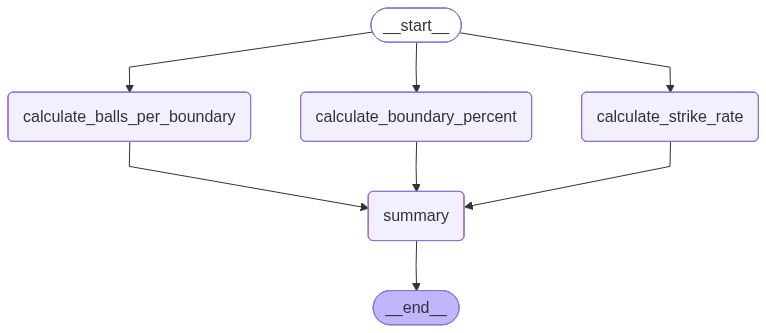

In [8]:
workflow

In [9]:
initial_state = {
  "runs": 100,
  "balls": 50,
  "fours": 6,
  "sixes": 4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4,
    'strike_rate': 200.0,
    'balls_per_boundary': 5.0,
    'boundary_percent': 48.0,
    'summary': '\nStrike Rate: 200.0\nBalls per Boundary: 5.0\nBoundary Percent: 48.0%\n'
}